In [1]:
from glob import glob
import os, torch, nibabel as nib
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

class WORDdataset(Dataset):
    def __init__(self, mode=None, root_dir="/mnt2/dataset/WORD", transform=None):
        super().__init__()
        self.transform = transform
        if mode == 'train':
            self.imgs_path  = sorted(glob(os.path.join(root_dir, 'imagesTr', '*.nii.gz')))
            self.masks_path = sorted(glob(os.path.join(root_dir, 'labelsTr', '*.nii.gz')))
        elif mode == 'val':
            self.imgs_path  = sorted(glob(os.path.join(root_dir, 'imagesVal', '*.nii.gz')))
            self.masks_path = sorted(glob(os.path.join(root_dir, 'labelsVal', '*.nii.gz')))
        else:                         
            self.imgs_path  = sorted(glob(os.path.join(root_dir, 'imagesTs', '*.nii.gz')))
            self.masks_path = None

    def __len__(self):  return len(self.imgs_path)

    def __getitem__(self, idx):
        img  = torch.from_numpy(nib.load(self.imgs_path[idx]).get_fdata()).float()
        if self.masks_path is None:
            return img
        mask = torch.from_numpy(nib.load(self.masks_path[idx]).get_fdata()).float()
        return img, mask

ds = WORDdataset(mode='train')
print(f"Loaded {len(ds)} volume pairs.")


Loaded 100 volume pairs.


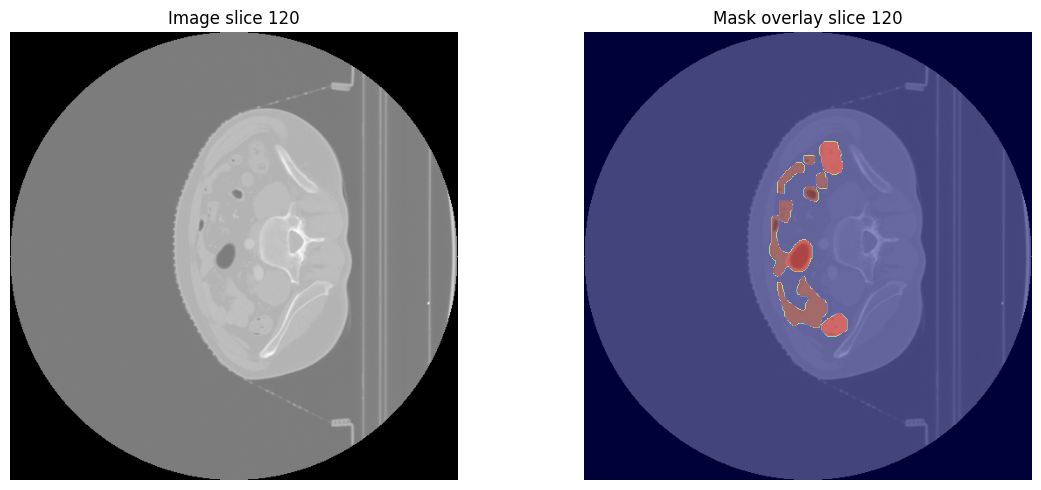

In [ ]:
idx        = 0
img, mask  = ds[idx]
# img.shape: (H, W, D) -> (512, 512, 241)
# img.shape[-1]: D -> 241
depth      = img.shape[-1]//2
img_slice  = img[:,:,depth].numpy()
mask_slice = mask[:,:,depth].numpy()

img_norm   = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img_norm, cmap='gray'); plt.title(f'Image slice {depth}')
plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_norm, cmap='gray'); 
plt.imshow(mask_slice, cmap='jet', alpha=0.45)
plt.title(f'Mask overlay slice {depth}')
plt.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
from ipywidgets import interact, IntSlider

def view_volume(vol_idx=0, z=0):
    img, mask  = ds[vol_idx]
    img_slice  = img[:,:,z].numpy()
    mask_slice = mask[:,:,z].numpy()
    img_norm   = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())

    plt.figure(figsize=(6,6))
    plt.imshow(img_norm, cmap='gray')
    plt.imshow(mask_slice, cmap='jet', alpha=0.35)
    plt.title(f'Volume {vol_idx} | slice {z}')
    plt.axis('off')
    plt.show()

max_z = ds[0][0].shape[-1]-1
interact(view_volume,
         vol_idx=IntSlider(min=0, max=len(ds)-1, step=1, value=0),
         z=IntSlider(min=0, max=max_z,step=1, value=max_z//2))


interactive(children=(IntSlider(value=0, description='vol_idx', max=99), IntSlider(value=120, description='z',…

<function __main__.view_volume(vol_idx=0, z=0)>